# Fire analysis


In [1]:
DB_FILE = "fire.duckdb"
STATE = "OR"

## DuckDB / SQL Magic setup

Using [JupySQL](https://jupysql.readthedocs.io/). [Docs from DuckDB.](https://duckdb.org/docs/current/guides/python/jupyter)


In [2]:
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False

In [3]:
import duckdb

%load_ext sql
conn = duckdb.connect(DB_FILE)
%sql conn --alias duckdb

Tip: You may define configurations in /Users/afeld/dev/ptps-wildfire-demo/pyproject.toml or /Users/afeld/.jupysql/config.

Did not find user configurations in /Users/afeld/dev/ptps-wildfire-demo/pyproject.toml.

In [4]:
from helpers import run_script_in_db


run_script_in_db(conn, "setup.sql")
run_script_in_db(conn, "views.sql")

In [5]:
import pandas as pd

pd.set_option("display.max_columns", 100)

## Burn probabilities


https://jupysql.readthedocs.io/en/docs/plot.html#histogram


Text(0.5, 1.0, 'Burn probability distribution')

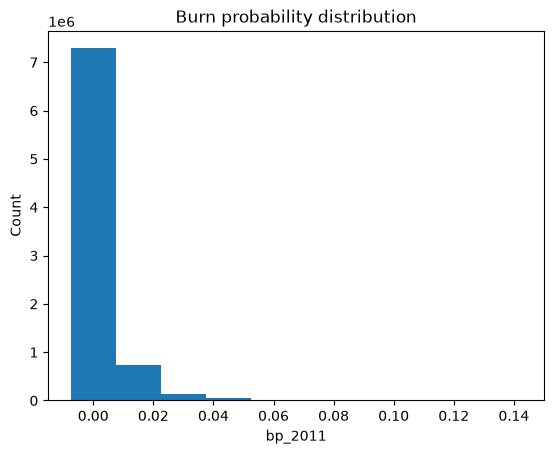

In [6]:
ax = %sqlplot histogram --table burn_prob_1km --column bp_2011 --bins 10
ax.set_title("Burn probability distribution")


In [7]:
from lonboard import Map, ScatterplotLayer

from helpers import to_continuous_color_map

PROBABILITY_PERCENTILE = 0.95

query = f"""
SELECT
    point,
    bp_2011
FROM burn_prob_1km
WHERE bp_2011 > (
    SELECT percentile_cont({PROBABILITY_PERCENTILE}) WITHIN GROUP (ORDER BY bp_2011) AS cutoff
    FROM burn_prob_1km
);
"""

values = conn.execute(query).df()["bp_2011"]
colors = to_continuous_color_map(values, "OrRd")

layer = ScatterplotLayer.from_duckdb(
    query,
    conn,
    crs="EPSG:4326",
    get_fill_color=colors,
    radius_min_pixels=2,
    radius_scale=500,
    radius_units="meters",
)
m = Map(layer)
m

## State-level


In [8]:
%%sql
SELECT COUNT(*)
FROM burn_prob_1km AS bp
INNER JOIN state_boundaries AS state
    ON ST_Contains(state.geom, bp.point)
WHERE state.stusps = '{{STATE}}';

,count_star()
0,272935


In [9]:
query = f"""
SELECT
    bp.point,
    bp.bp_2011
FROM burn_prob_1km AS bp
INNER JOIN state_boundaries AS state
    ON ST_Contains(state.geom, bp.point)
WHERE state.stusps = '{STATE}'
"""

values = conn.execute(query).df()["bp_2011"]
# match color scheme for Wildfire Hazard Potential to compare
# https://experience.arcgis.com/experience/78e7e78bcef64dfc98cf13e2e0eae156
colors = to_continuous_color_map(values, "RdYlGn_r")

layer = ScatterplotLayer.from_duckdb(
    query,
    conn,
    crs="EPSG:4326",
    get_fill_color=colors,
    radius_min_pixels=2,
    radius_scale=500,
    radius_units="meters",
)
m = Map(layer)
m

## Red flag alerts


In [10]:
from helpers import get_geo_df

raw_alerts = get_geo_df(
    conn,
    """
    SELECT *
    FROM red_flag_warnings
    ORDER BY effective DESC
    """,
)
raw_alerts

,OGC_FID,@id,@type,id,areaDesc,geocode,affectedZones,references,sent,effective,onset,expires,ends,status,messageType,category,severity,certainty,urgency,event,sender,senderName,headline,description,instruction,response,note,parameters,scope,code,language,web,eventCode,geom
0,0,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Lincoln and Uinta Counties/Lower Elevations; U...,"{ ""SAME"": [ ""056023"", ""056035"", ""056037"", ""056...","[https://api.weather.gov/zones/fire/WYZ277, ht...",[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...",None
1,1,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Natrona County/Casper BLM; Johnson County/Casp...,"{ ""SAME"": [ ""056013"", ""056019"", ""056025"", ""056...","[https://api.weather.gov/zones/fire/WYZ280, ht...",[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...",None
2,2,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Upper Wind River Basin/Wind River Basin; Owl C...,"{ ""SAME"": [ ""056013"", ""056025"", ""056017"", ""056...","[https://api.weather.gov/zones/fire/WYZ283, ht...",[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...",None
3,3,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Absaroka Mountains/North Shoshone NF,"{ ""SAME"": [ ""056013"", ""056017"", ""056029"" ], ""U...",[https://api.weather.gov/zones/fire/WYZ286],[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...",None
4,4,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.ed0385aef8fe1067d7f30b1...,Upper Snake River Valley/Idaho Falls BLM; Midd...,"{ ""SAME"": [ ""016005"", ""016011"", ""016013"", ""016...","[https://api.weather.gov/zones/fire/IDZ410, ht...","[ { ""@id"": ""https:\/\/api.weather.gov\/alerts\...",2026-08-09 22:02:00-04:00,2026-08-09 22:02:00-04:00,2026-08-10 10:00

### Geometries

[The alerts/zones APIs don't include the geometry](https://github.com/weather-gov/api/discussions/278), so backfill them.


In [11]:
import requests
import shapely

from helpers import get_geo_df

zones = get_geo_df(
    conn,
    """
    SELECT DISTINCT
        unnest(affectedZones) AS zone_url,
        geom
    FROM red_flag_warnings
    ORDER BY zone_url
    """,
)


def get_zone_geom(url: str):
    response = requests.get(url)
    geom = response.json()["geometry"]
    return shapely.geometry.shape(geom)


zone_urls = zones["zone_url"]
zones = zones.assign(geom=zone_urls.apply(get_zone_geom))  # pyright: ignore[reportArgumentType, reportCallIssue]
zones

,zone_url,geom
0,https://api.weather.gov/zones/fire/IDZ410,"POLYGON ((-111.55316 44.4876, -111.55382 44.47..."
1,https://api.weather.gov/zones/fire/IDZ425,"POLYGON ((-113.42079 43.56981, -113.41575 43.5..."
2,https://api.weather.gov/zones/fire/IDZ475,"POLYGON ((-113.9809 45.70271, -113.9736 45.702..."
3,https://api.weather.gov/zones/fire/IDZ476,"POLYGON ((-113.88463 45.38238, -113.84451 45.3..."
4,https://api.weather.gov/zones/fire/SDZ322,"POLYGON ((-103.64998 43.53333, -103.46469 43.4..."
5,https://api.weather.gov/zones/fire/WYZ277,"POLYGON ((-110.83705 42.23298, -110.8369 42.18..."
6,https://api.weather.gov/zones/fire/WYZ278,"POLYGON ((-109.98984 43.22111, -109.99048 43.1..."
7,https://api.weather.gov/zones/fire/WYZ279,"POLYGON ((-108.103 42.22896, -108.0876 42.2241..."
8,https://api.weather.gov/zones/fire/WYZ280,"POLYGON ((-106.0734 43.19791, -106.0737 43.142..."
9,https://api.weather.gov/zones/fire/WYZ281,"POLYGON ((-106.0097 44.56401, -106.0085 44.521..."


In [12]:
def get_alert_geom(row: pd.Series):
    """Returns the unified geometry for all affected zones"""

    alert_zones = zones[zones["zone_url"].isin(row["affectedZones"])]
    return alert_zones.union_all("unary")


alerts = raw_alerts.assign(geom=raw_alerts.apply(get_alert_geom, axis=1))  # pyright: ignore[reportArgumentType]
alerts

,OGC_FID,@id,@type,id,areaDesc,geocode,affectedZones,references,sent,effective,onset,expires,ends,status,messageType,category,severity,certainty,urgency,event,sender,senderName,headline,description,instruction,response,note,parameters,scope,code,language,web,eventCode,geom
0,0,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Lincoln and Uinta Counties/Lower Elevations; U...,"{ ""SAME"": [ ""056023"", ""056035"", ""056037"", ""056...","[https://api.weather.gov/zones/fire/WYZ277, ht...",[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...","POLYGON ((-108.0876 42.22416, -108.0794 42.226..."
1,1,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Natrona County/Casper BLM; Johnson County/Casp...,"{ ""SAME"": [ ""056013"", ""056019"", ""056025"", ""056...","[https://api.weather.gov/zones/fire/WYZ280, ht...",[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...","POLYGON ((-106.0758 42.69291, -106.07601 42.65..."
2,2,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Upper Wind River Basin/Wind River Basin; Owl C...,"{ ""SAME"": [ ""056013"", ""056025"", ""056017"", ""056...","[https://api.weather.gov/zones/fire/WYZ283, ht...",[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...","POLYGON ((-107.4795 42.93056, -107.4645 42.926..."
3,3,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.6ea079f0778d9fe2638213b...,Absaroka Mountains/North Shoshone NF,"{ ""SAME"": [ ""056013"", ""056017"", ""056029"" ], ""U...",[https://api.weather.gov/zones/fire/WYZ286],[ ],2026-08-09 22:23:00-04:00,2026-08-09 22:23:00-04:00,2026-08-10 08:00:00-04:00,2026-08-10 12:00:00-04:00,2026-08-10 17:00:00-04:00,Actual,Alert,Met,Severe,Likely,Expected,Red Flag Warning,w-nws.webmaster@noaa.gov,NWS Riverton WY,Red Flag Warning issued August 10 at 2:23AM MD...,The National Weather Service in Riverton has i...,A Red Flag Warning means that critical fire we...,Prepare,None,"{ ""AWIPSidentifier"": [ ""RFWRIW"" ], ""WMOidentif...",Public,IPAWSv1.0,en-US,http://www.weather.gov,"{ ""SAME"": [ ""NWS"" ], ""NationalWeatherService"":...","POLYGON ((-108.85994 43.83903, -108.8654 43.83..."
4,4,https://api.weather.gov/alerts/urn:oid:2.49.0....,wx:Alert,urn:oid:2.49.0.1.840.0.ed0385aef8fe1067d7f30b1...,Upper Snake River Valley/Idaho Falls BLM; Midd...,"{ ""SAME"": [ ""016005"", ""016011"", ""016013"

### Map


In [13]:
from lonboard import PolygonLayer

layer = PolygonLayer.from_geopandas(
    alerts,
    # crs="EPSG:4326",
    get_fill_color=[255, 0, 0],
)
m = Map(layer)
m

/Users/afeld/dev/ptps-wildfire-demo/.venv/lib/python3.14/site-packages/lonboard/_geoarrow/ops/reproject.py:40: UserWarning: No CRS exists on data. If no data is shown on the map, double check that your CRS is WGS84.
  warn(


## Active fires


### Query data

> Each MODIS active fire/thermal hotspot location represents the center of a 1km pixel that is flagged by the algorithm as containing one or more fires within the pixel.

https://www.earthdata.nasa.gov/data/tools/firms

https://firms.modaps.eosdis.nasa.gov/active_fire/#firms-txt


In [14]:
%%sql
SELECT *
FROM active_fires
LIMIT 10;


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,bright_t31,frp,daynight
0,45.29657,-69.49461,326.35,1.42,1.18,2026-08-09,0026,T,100,6.1NRT,286.45,41.08,N
1,18.31891,-88.33073,316.88,2.35,1.48,2026-08-09,0158,T,92,6.1NRT,293.69,42.97,N
2,18.31735,-88.33570,314.31,2.35,1.48,2026-08-09,0158,T,88,6.1NRT,293.83,36.78,N
3,20.72093,-76.02602,306.44,1.95,1.36,2026-08-09,0158,T,45,6.1NRT,290.02,14.14,N
4,19.39528,-92.03804,306.85,4.28,1.91,2026-08-09,0158,T,49,6.1NRT,292.19,36.88,N
5,19.40042,-92.04571,305.32,4.28,1.91,2026-08-09,0158,T,27,6.1NRT,292.26,30.11,N
6,20.54469,-87.33319,314.37,1.78,1.31,2026-08-09,0158,T,89,6.1NRT,292.90,25.21,N
7,21.53366,-87.03705,305.53,1.62,1.25,2026-08-09,0158,T,54,6.1NRT,294.12,8.01,N
8,21.54455,-87.03920,328.75,1.62,1.25,2026-08-09,0158,T,100,6.1NRT,294.33,49.83,N
9,41.45987,-81.67714,302.94,1.55,1.23,2026-08-09,0204,T,52,6.1NRT,290.15,11.42,N
